<a href="https://colab.research.google.com/github/Nounsidev/PyTorch_Learning/blob/main/4_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import sklearn

In [58]:

from sklearn.datasets import make_circles

nSamples = 1000

X, y = make_circles(nSamples, noise = 0.03, random_state = 42)

len(X), len(y)

(1000, 1000)

In [59]:
print(f"First 5 samples:\n {X[:5]}")
print(f"First 5 labels:\n {y[:5]}")

First 5 samples:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 labels:
 [1 1 1 1 0]


In [60]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


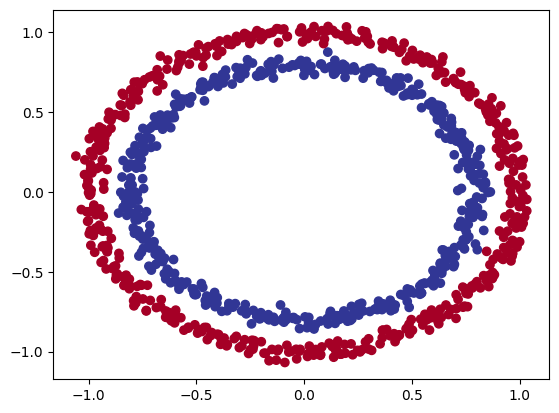

In [61]:
import matplotlib.pyplot as plt

plt.scatter(x = X[:, 0],
            y = X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu);

In [62]:
X.shape, y.shape

((1000, 2), (1000,))

In [63]:
#1. Turn Data into tensors
import torch
torch.__version__

'2.11.0+cu128'

In [64]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [65]:
type(X)

torch.Tensor

In [66]:
#Split Data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [67]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [68]:
#2. BUILDING MODEL
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [69]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    #Create layer data capable of handling the shapes of our data
    self.layer_1 = nn.Linear(in_features=2, out_features = 5) #takes in 2 feature and upscale
    self.layer_2 = nn.Linear(in_features=5, out_features = 1) #output features

  #Forward Pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x))


modelZero = CircleModelV0().to(device)
modelZero

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [70]:
next(modelZero.parameters()).device

device(type='cuda', index=0)

In [71]:
modelZero = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

modelZero

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [72]:
modelZero.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [73]:
# MAKE PREDICTIONS

untrainedPreds = modelZero(X_test.to(device))
print(f"Length of predictions: {len(untrainedPreds)}, Shape: {untrainedPreds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n {untrainedPreds[:10]}")
print(f"\nFirst 10 test labels:\n {y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
 tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [74]:
# Loss funtion and optimizer

lossFunc = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(modelZero.parameters(), lr = 0.1)

In [75]:
#Calculate accuracy
def Accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [76]:
# 3. TRAINING A MODEL
# 3.1 Going from raw logits -> pred prob -> pred labels

modelZero.eval()
with torch.inference_mode():
  y_logits = modelZero(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [77]:
# Use sigmoid action func on our model logits to turn them into prediction probs

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [78]:
y_preds = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(modelZero(X_test.to(device))[:5]))

print(torch.eq(y_pred_labels.squeeze(), y_preds.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [79]:
### 3.2 BUILDING TRAIN AND TEST LOOP
torch.manual_seed(42)

#Set number of epoch
epochs = 1000

#Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#Build training and evaluation loop
for epoch in range(epochs):
  modelZero.train()
  y_logits = modelZero(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) #turn logits -> pred probs -> pred labels

  loss = lossFunc(y_logits, y_train)
  acc = Accuracy_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()

  #Back propagation
  loss.backward()

  #Gradient Descent
  optimizer.step()

  modelZero.eval()
  with torch.inference_mode():
    # 1. FORWARD PASS
    test_logits = modelZero(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. CALCULATE LOSS
    test_loss = lossFunc(test_logits, y_test)
    test_acc = Accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796 | Accuracy: 51.88% | Test Loss: 0.69440 | Test Accuracy: 58.00%
Epoch: 10 | Loss: 0.69590 | Accuracy: 51.25% | Test Loss: 0.69305 | Test Accuracy: 53.00%
Epoch: 20 | Loss: 0.69490 | Accuracy: 51.62% | Test Loss: 0.69254 | Test Accuracy: 49.50%
Epoch: 30 | Loss: 0.69435 | Accuracy: 51.12% | Test Loss: 0.69236 | Test Accuracy: 49.50%
Epoch: 40 | Loss: 0.69401 | Accuracy: 50.88% | Test Loss: 0.69232 | Test Accuracy: 51.00%
Epoch: 50 | Loss: 0.69378 | Accuracy: 50.25% | Test Loss: 0.69234 | Test Accuracy: 50.00%
Epoch: 60 | Loss: 0.69362 | Accuracy: 50.00% | Test Loss: 0.69239 | Test Accuracy: 51.50%
Epoch: 70 | Loss: 0.69351 | Accuracy: 50.25% | Test Loss: 0.69246 | Test Accuracy: 51.00%
Epoch: 80 | Loss: 0.69342 | Accuracy: 49.88% | Test Loss: 0.69254 | Test Accuracy: 50.00%
Epoch: 90 | Loss: 0.69336 | Accuracy: 49.88% | Test Loss: 0.69262 | Test Accuracy: 53.00%
Epoch: 100 | Loss: 0.69331 | Accuracy: 49.25% | Test Loss: 0.69271 | Test Accuracy: 53.00%
Epoch: 110

In [80]:
# 4. PREDICTION
import requests
from pathlib import Path

# Download helper functions
if Path("helper_functions.py").is_file():
  print("Helper functions already downloaded")
else:
  print("Downloading helper functions...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")

  #Write Binary
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


Helper functions already downloaded


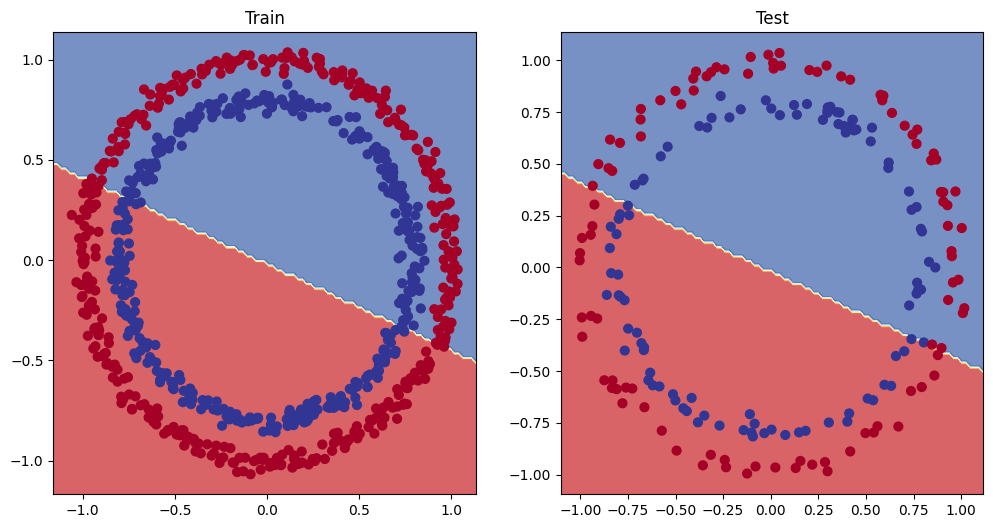

In [81]:
plt.figure(figsize=(12, 6))

#TRAIN PLOT
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelZero, X_train, y_train)

#TEST PLOT
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelZero, X_test, y_test)

In [87]:
# 5. IMPROVING MODEL
# 5.1 BUILD MODEL
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

modelV1 = CircleModelV1().to(device)
modelV1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [88]:
#5.2 LOSS AND OPTIMIZER

lossFunc = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(modelZero.parameters(), lr = 0.01)

In [89]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  modelV1.train()

  #Forward Pass
  y_logits = modelV1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  #Calculate Loss
  loss = lossFunc(y_logits, y_train)
  acc = Accuracy_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # TESTING
  modelV1.eval()
  with torch.inference_mode():
    test_logits = modelV1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = lossFunc(test_logits, y_test)
    test_acc = Accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 200 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 300 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 400 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 500 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 600 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 700 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 800 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 900 | Loss: 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%


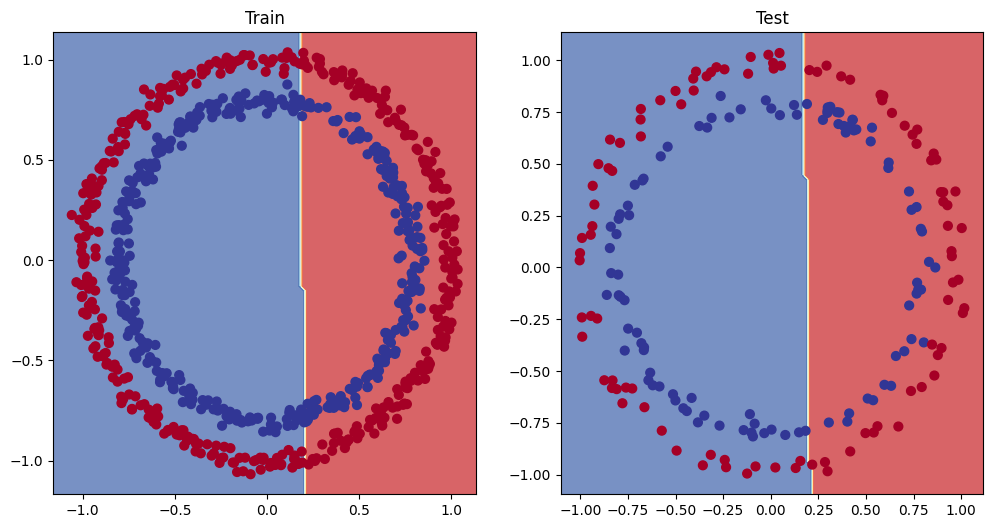

In [91]:
plt.figure(figsize=(12, 6))

#TRAIN PLOT
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV1, X_train, y_train)

#TEST PLOT
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV1, X_test, y_test)

In [93]:
# 5.2 TROUBLE SHOOTING WITH SMALLER DATASET

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.01

#Create Data
X_regression = torch.arange(start, end, step).unsqueeze(dim = 1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]



100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [95]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

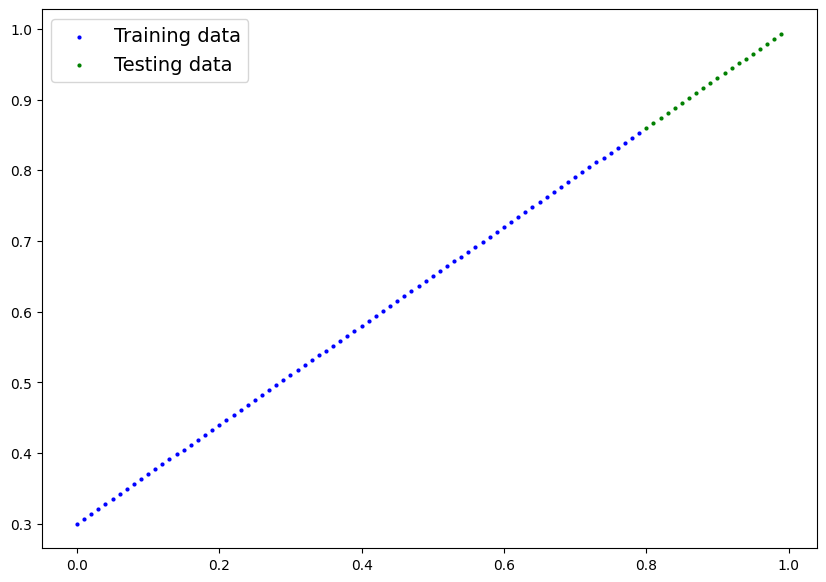

In [96]:
plot_predictions(X_train_regression, y_train_regression, X_test_regression, y_test_regression)

In [99]:
# 5.3 ADJUSTING MODEV1 to fit a straight line

modelV2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

modelV2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [100]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(modelV2.parameters(), lr = 0.01)

In [104]:
torch.manual_seed(38)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  modelV2.train()

  y_pred = modelV2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  modelV2.eval()
  with torch.inference_mode():
    test_pred = modelV2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.01317 | Test Loss: 0.00209
Epoch: 100 | Loss: 0.01343 | Test Loss: 0.00267
Epoch: 200 | Loss: 0.01349 | Test Loss: 0.00264
Epoch: 300 | Loss: 0.01325 | Test Loss: 0.00273
Epoch: 400 | Loss: 0.01281 | Test Loss: 0.00222
Epoch: 500 | Loss: 0.01301 | Test Loss: 0.00266
Epoch: 600 | Loss: 0.01300 | Test Loss: 0.00247
Epoch: 700 | Loss: 0.01270 | Test Loss: 0.00241
Epoch: 800 | Loss: 0.01265 | Test Loss: 0.00211
Epoch: 900 | Loss: 0.01248 | Test Loss: 0.00254
